# California Housing Value Prediction
## End-to-End Data Science Case Study

**Objective:** Predict median house values using California housing census-tract data.

**Target Variable:** `median_house_value`

**Dataset:** California Housing Prices — Kaggle

START TO IMPORT THE LIBRARIES

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

LOAD THE DATA

In [3]:
DATA_PATH = Path("../data/housing.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print ("First 5 rows of the dataset:")
print(df.head())
print("shape of the dataset:", df.shape)

Dataset loaded successfully!
First 5 rows of the dataset:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
shape of the data

In [4]:
correlation_matrix = df.select_dtypes(include="number").corr()

correlation_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


INSPECT THE DATASETS SYSTEMATICALLY

In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(20640, 10)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income     

Descriptive Statistics

In [6]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


DATA QUALITY AUDIT

In [7]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value  

AUDIT TABLE

In [8]:
audit = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique()
})

audit

,Column,Data Type,Missing Values,Missing %,Unique Values
longitude,longitude,float64,0,0.0,844
latitude,latitude,float64,0,0.0,862
housing_median_age,housing_median_age,float64,0,0.0,52
total_rooms,total_rooms,float64,0,0.0,5926
total_bedrooms,total_bedrooms,float64,207,1.0,1923
population,population,float64,0,0.0,3888
households,households,float64,0,0.0,1815
median_income,median_income,float64,0,0.0,12928
median_house_value,median_house_value,float64,0,0.0,3842
ocean_proximity,ocean_proximity,str,0,0.0,5


### Data Quality Audit Findings

- The dataset contains 20,640 observations and 10 columns.
- `total_bedrooms` contains 207 missing values, representing approximately 1% of the dataset.
- All other columns have no missing values.
- The dataset contains numerical features along with the categorical feature `ocean_proximity`.
- `ocean_proximity` contains 5 unique categories.
- Missing values have been identified but have not yet been treated at this stage.

categorical inspection

In [9]:
df["ocean_proximity"].value_counts()


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [10]:
df["ocean_proximity"].value_counts(normalize=True).mul(100).round(2)

ocean_proximity
<1H OCEAN     44.26
INLAND        31.74
NEAR OCEAN    12.88
NEAR BAY      11.09
ISLAND         0.02
Name: proportion, dtype: float64

Exploratory Data Analysis (EDA) & Visualization

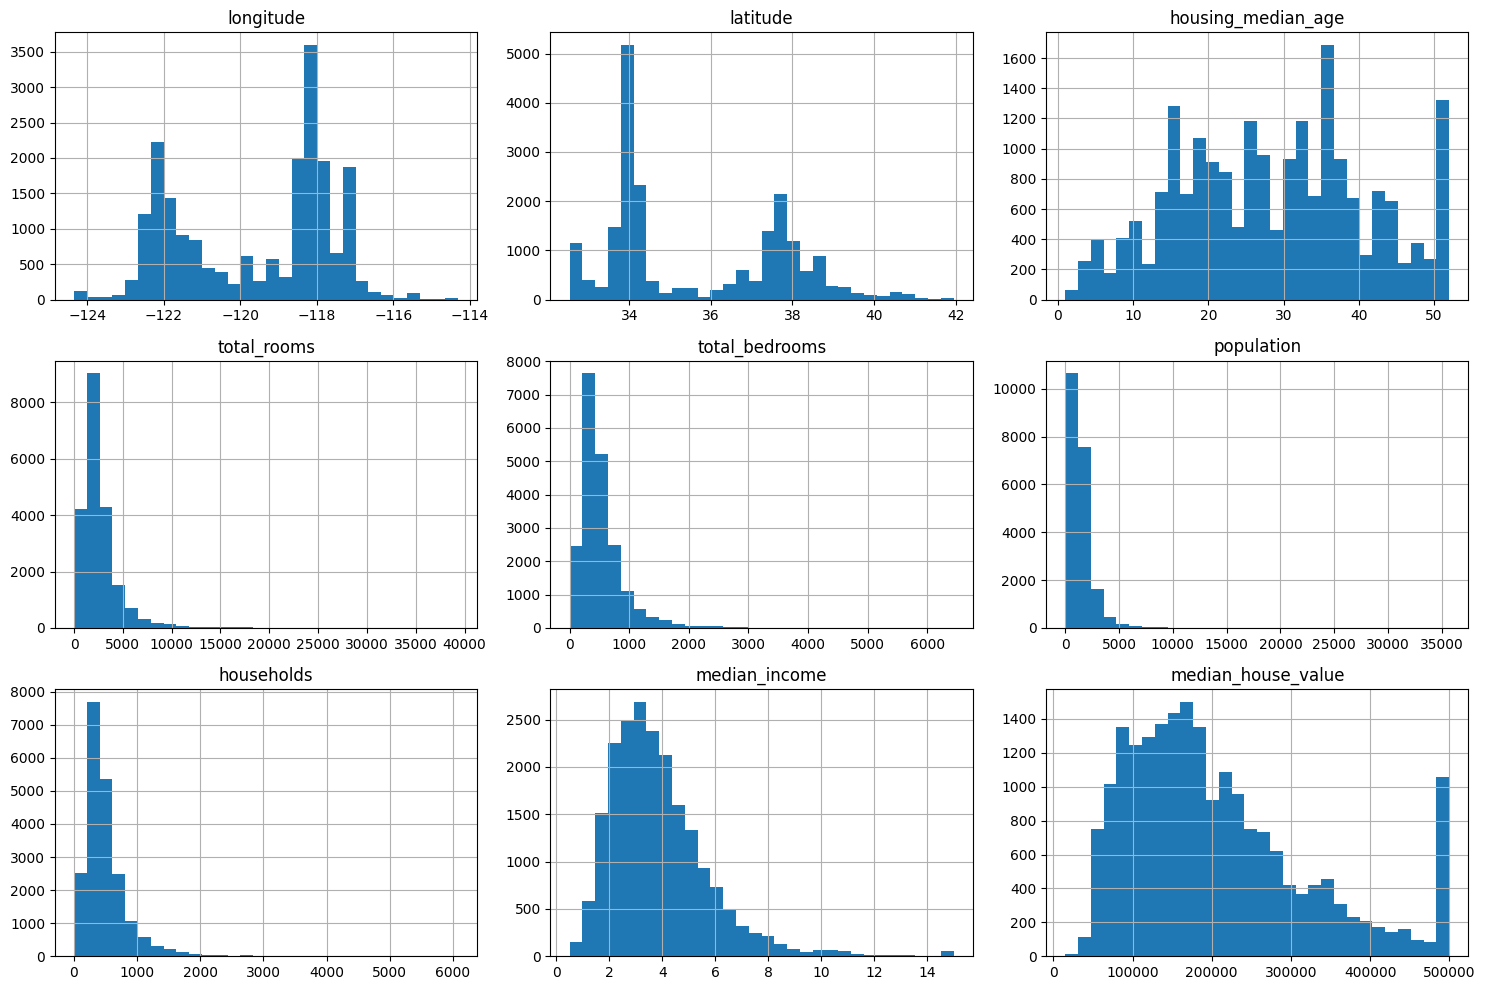

In [11]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

### EDA - Distribution Findings

- Several demographic and housing-count variables exhibit strong right-skewed distributions.
- `total_rooms`, `total_bedrooms`, `population`, and `households` contain long upper tails.
- `median_income` is concentrated in the lower-to-middle range with a right tail.
- `median_house_value` shows a notable concentration at approximately $500,000, which requires further investigation.
- Geographic variables (`longitude` and `latitude`) exhibit non-uniform spatial distributions.
- `housing_median_age` has a bounded range with a maximum around 52.

The histograms showed us that several variables have long right tails. Now we need to investigate whether those extreme values could be considered potential outliers.

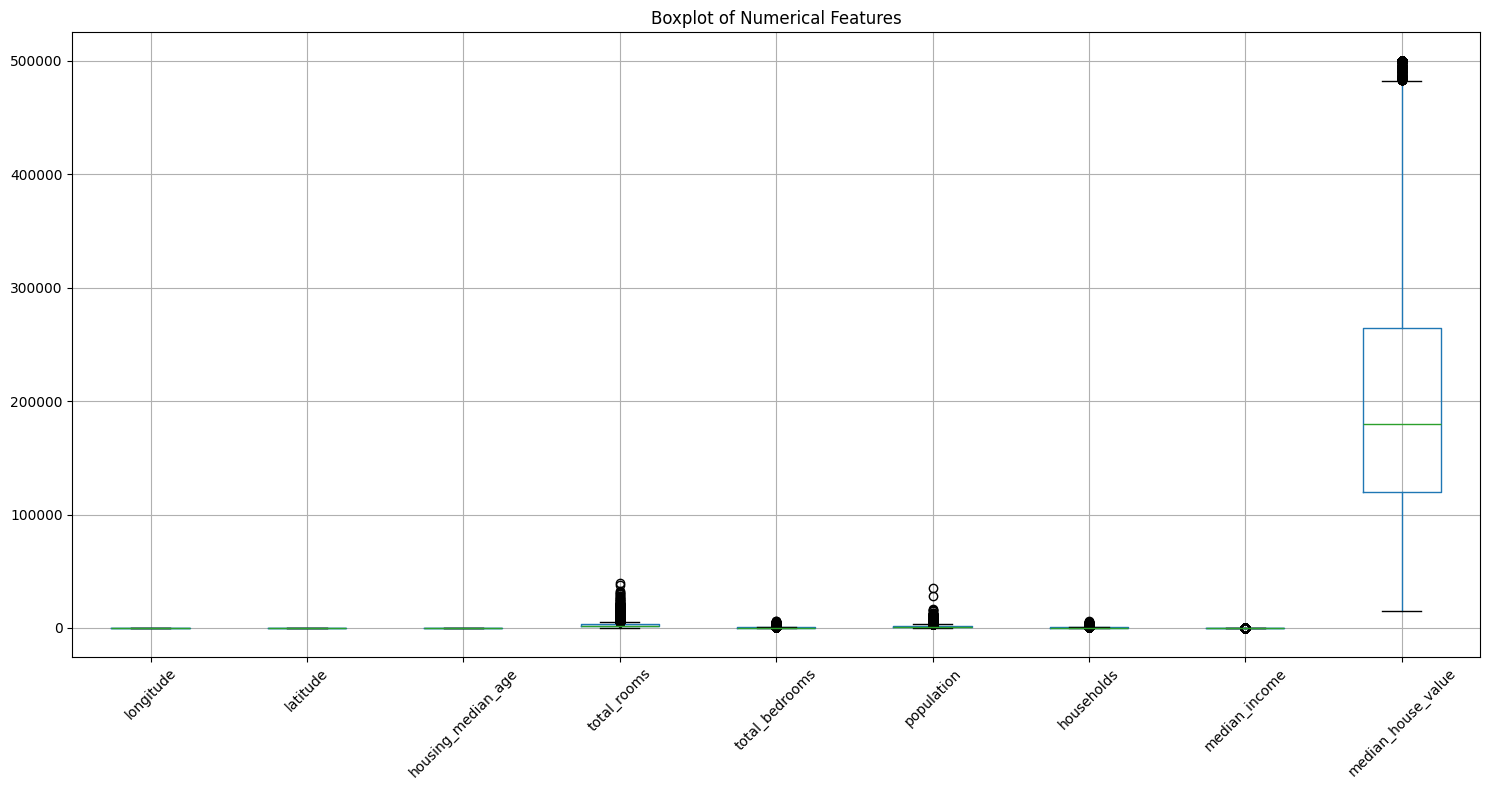

In [12]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(15, 8))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.tight_layout()
plt.show()

calculate the actual outlier counts

In [13]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR




    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers.count(),
        "Outlier %": round(outliers.count() / df[col].notna().sum() * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,longitude,-121.8000,-118.01000,3.79000,-127.485000,-112.325000,0,0.00
1,latitude,33.9300,37.71000,3.78000,28.260000,43.380000,0,0.00
2,housing_median_age,18.0000,37.00000,19.00000,-10.500000,65.500000,0,0.00
3,total_rooms,1447.7500,3148.00000,1700.25000,-1102.625000,5698.375000,1287,6.24
4,total_bedrooms,296.0000,647.00000,351.00000,-230.500000,1173.500000,1271,6.22
5,population,787.0000,1725.00000,938.00000,-620.000000,3132.000000,1196,5.79
6,households,280.0000,605.00000,325.00000,-207.500000,1092.500000,1220,5.91
7,median_income,2.5634,4.74325,2.17985,-0.706375,8.013025,681,3.30
8,median_house_value,119600.0000,264725.00000,145125.00000,-98087.500000,482412.500000,1071,5.19


“The IQR analysis identified potential outliers primarily in the housing-size, population, income, and house-value variables. These observations were retained initially because they may represent genuine variations in the underlying data rather than data-entry errors.”

### Outlier Analysis

The IQR-based analysis identified potential outliers in several numerical features.

The highest proportions were observed in `total_rooms` (6.24%), 
`total_bedrooms` (6.22%), `households` (5.91%), and `population` (5.79%).

These observations are flagged as potential outliers based on the 
1.5 × IQR rule. They are not automatically treated as erroneous 
because extreme housing and population values may represent legitimate 
census-tract characteristics.

Outlier treatment will therefore be considered after understanding 
the distributions and business context.

**CORRELATION MATRIX**

In [14]:
correlation_matrix = df.select_dtypes(include="number").corr()

correlation_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


Create a cleaner target-correlation output

In [15]:
target_corr = (
    correlation_matrix["median_house_value"]
    .sort_values(ascending=False)
)

target_corr

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

*Numbers are useful, but visualization makes the relationship much easier to understand.*

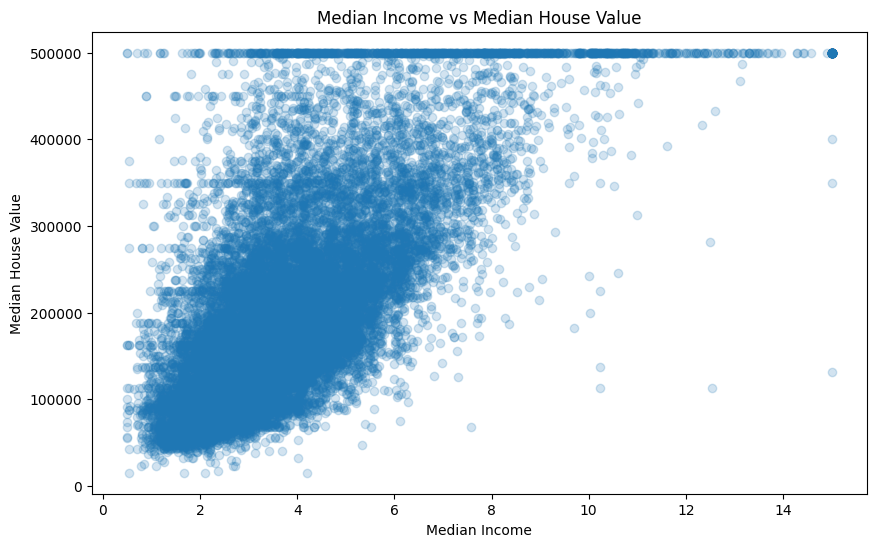

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["median_income"],
    df["median_house_value"],
    alpha=0.2
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()

### Median Income vs Median House Value

The scatter plot shows a positive relationship between median income and median house value.

Higher-income areas generally tend to have higher house values. A concentration of values around $500,000 is also visible and will be investigated further.

<Figure size 1000x600 with 0 Axes>

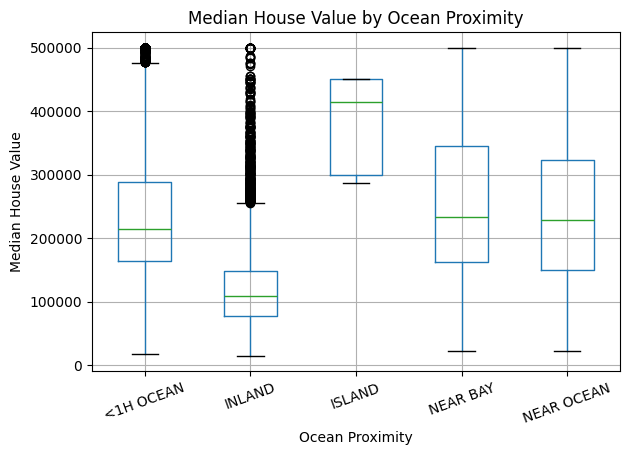

In [17]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="median_house_value",
    by="ocean_proximity"
)

plt.title("Median House Value by Ocean Proximity")
plt.suptitle("")
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### House Value by Ocean Proximity

House values vary across ocean-proximity categories. Inland areas generally show lower house values, while coastal categories tend to have higher distributions.

The `ISLAND` category contains only 5 observations, so its distribution should be interpreted cautiously.

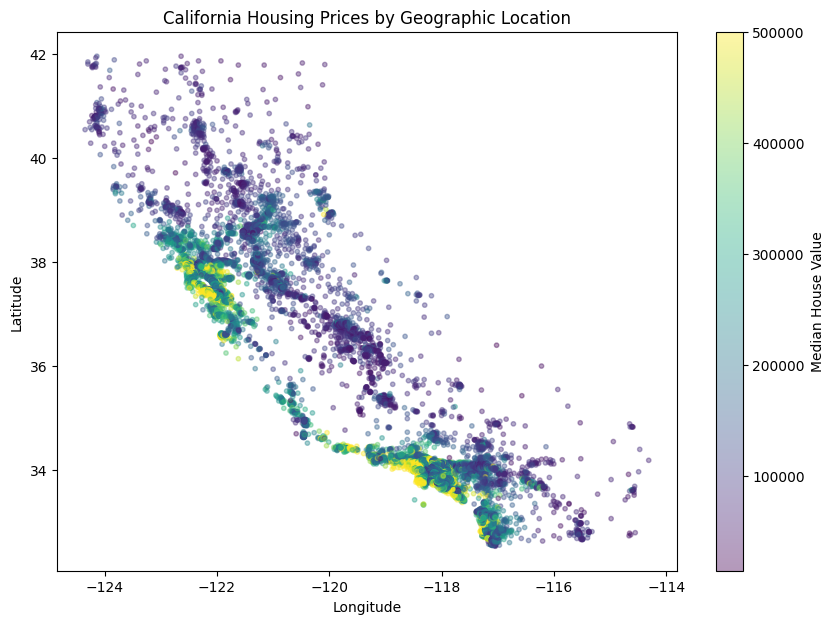

In [18]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    alpha=0.4,
    s=10
)

plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices by Geographic Location")

plt.show()

**"I observed that houses located closer to the coast tend to have higher median house values compared with many inland areas. The spatial plot also shows that house values are geographically clustered, suggesting that location is an important factor in the dataset."**

In [19]:
df["median_house_value"].value_counts().head(10)

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
225000.0     92
350000.0     79
87500.0      78
275000.0     65
150000.0     64
Name: count, dtype: int64

In [20]:
print(
    "Number of houses valued at $500,000 or above:",
    (df["median_house_value"] >= 500000).sum()
)

Number of houses valued at $500,000 or above: 992


***Approximately 4.81% of observations have a recorded median house value of at least $500,000, with 965 observations exactly at $500,001. This concentration suggests a capped upper range in the target variable and should be considered during modeling and error analysis.***

Create a correlation heatmap

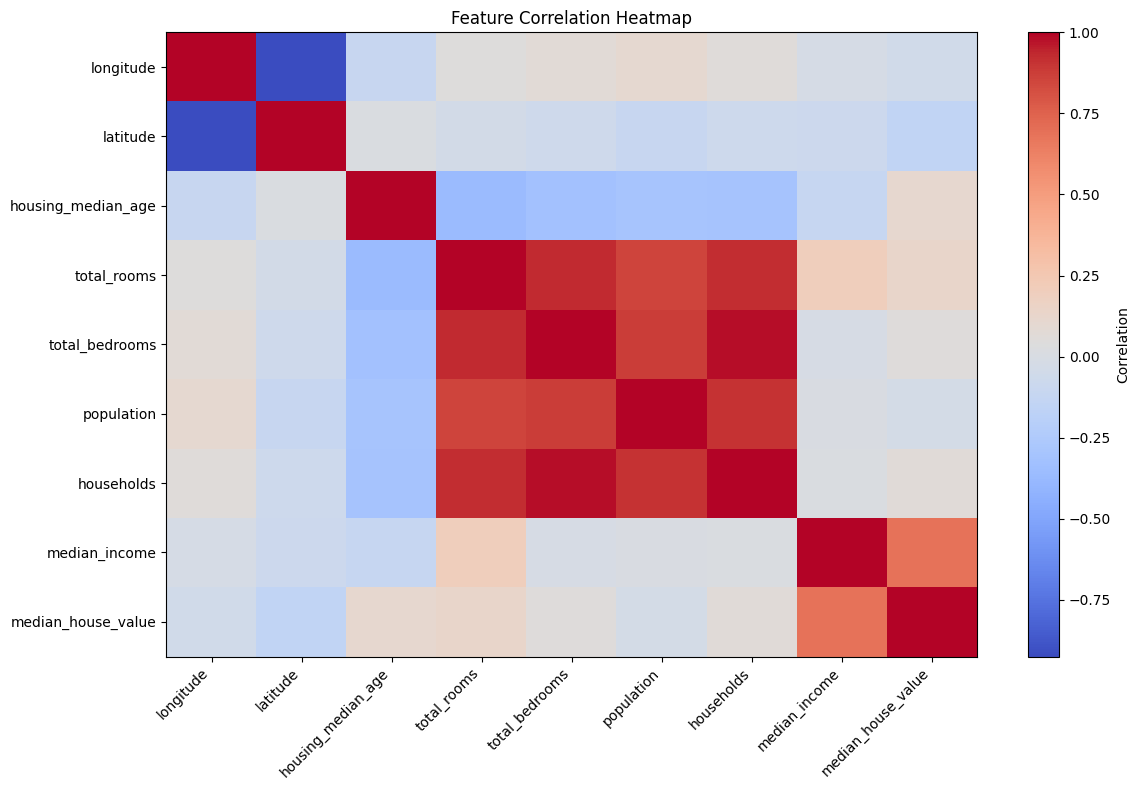

In [21]:
plt.figure(figsize=(12, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Correlation Analysis

The correlation heatmap shows strong relationships among `total_rooms`,
`total_bedrooms`, and `households`, indicating potential multicollinearity.

`median_income` has the strongest linear association with
`median_house_value` (correlation ≈ 0.69).

**IMPORT VIF**

In [22]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

**PREPARE THE NUMERICAL FEATURES**

In [24]:
X_vif = df.select_dtypes(include="number").drop(
    columns=["median_house_value"]
)

X_vif = X_vif.dropna()

**CALCULATE VIF**

In [25]:
vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
4,total_bedrooms,36.003726
6,households,35.136045
3,total_rooms,12.717000
1,latitude,8.828919
0,longitude,8.713740
5,population,6.371238
7,median_income,1.731511
2,housing_median_age,1.260015


### Multicollinearity Analysis using VIF

VIF analysis confirms substantial multicollinearity among `total_bedrooms`,
`households`, and `total_rooms`, with VIF values of approximately 36.0,
35.1, and 12.7 respectively.

Latitude, longitude, and population also show elevated VIF values, while
`median_income` and `housing_median_age` show relatively low VIF.

###FEATURE ENGINEERING###


In [26]:
df["rooms_per_household"] = (
    df["total_rooms"] / df["households"]
)

df[["total_rooms", "households", "rooms_per_household"]].head()

,total_rooms,households,rooms_per_household
0,880.0,126.0,6.984127
1,7099.0,1138.0,6.238137
2,1467.0,177.0,8.288136
3,1274.0,219.0,5.817352
4,1627.0,259.0,6.281853


In [27]:
df["bedrooms_per_room"] = (
    df["total_bedrooms"] / df["total_rooms"]
)

In [28]:
df[[
    "total_rooms",
    "total_bedrooms",
    "bedrooms_per_room"
]].head()

,total_rooms,total_bedrooms,bedrooms_per_room
0,880.0,129.0,0.146591
1,7099.0,1106.0,0.155797
2,1467.0,190.0,0.129516
3,1274.0,235.0,0.184458
4,1627.0,280.0,0.172096


In [29]:
df["population_per_household"] = (
    df["population"] / df["households"]
)

In [30]:
df[[
    "population",
    "households",
    "population_per_household"
]].head()

,population,households,population_per_household
0,322.0,126.0,2.555556
1,2401.0,1138.0,2.109842
2,496.0,177.0,2.802260
3,558.0,219.0,2.547945
4,565.0,259.0,2.181467


In [31]:
engineered_features = [
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household"
]

df[engineered_features + ["median_house_value"]].corr()["median_house_value"].sort_values(
    ascending=False
)

median_house_value          1.000000
rooms_per_household         0.151948
population_per_household   -0.023737
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

In [32]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

##ONE-HOT ENCODING##

In [33]:
df_encoded = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    dtype=int
)

In [34]:
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,0,0,0,1,0


In [35]:
df_encoded.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'rooms_per_household', 'bedrooms_per_room',
       'population_per_household', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='str')

**Create geographic grid features**

In [36]:
df["latitude_bin"] = pd.cut(
    df["latitude"],
    bins=10,
    labels=False
)

df["longitude_bin"] = pd.cut(
    df["longitude"],
    bins=10,
    labels=False
)

In [37]:
df[[
    "latitude",
    "longitude",
    "latitude_bin",
    "longitude_bin"
]].head()

,latitude,longitude,latitude_bin,longitude_bin
0,37.88,-122.23,5,2
1,37.86,-122.22,5,2
2,37.85,-122.24,5,2
3,37.85,-122.25,5,2
4,37.85,-122.25,5,2


##Separate target##

In [38]:
X = df.drop(columns=["median_house_value"])
y = df["median_house_value"]

##Train/Test Split##

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16512, 14)
X_test : (4128, 14)
y_train: (16512,)
y_test : (4128,)


In [41]:
##MISSING Values handling

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")


In [42]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["str"]
).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'latitude_bin', 'longitude_bin']

Categorical features:
['ocean_proximity']


##ColumnTransformer.##

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [44]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [45]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [46]:
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape :", X_test_processed.shape)

X_train_processed shape: (16512, 18)
X_test_processed shape : (4128, 18)


##Baseline Model##

In [47]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_processed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
y_pred = linear_model.predict(X_test_processed)
print(y_pred[:5])

[ 33565.77212693 152713.79917844 314434.68651246 291879.6379987
 262485.98005657]


##Calculate the baseline metrics##

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Baseline")
print("--------------------------")
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

Linear Regression Baseline
--------------------------
RMSE: 68057.86962468135
MAE : 48998.519376883734
R²  : 0.6465322128616688


##Ridge Regression##

In [50]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_processed, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [51]:
ridge_pred = ridge_model.predict(X_test_processed)

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Baseline")
print("-------------------------")
print("RMSE:", ridge_rmse)
print("MAE :", ridge_mae)
print("R²  :", ridge_r2)

Ridge Regression Baseline
-------------------------
RMSE: 68067.66874512285
MAE : 49004.93690019152
R²  : 0.6464304194088003


##GridSearchCV##

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge = Ridge()

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

ridge_grid.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate par

In [54]:
print("Best alpha:", ridge_grid.best_params_["alpha"])
print("Best CV RMSE:", -ridge_grid.best_score_)

Best alpha: 1
Best CV RMSE: 66883.19960510284


In [55]:
best_ridge = ridge_grid.best_estimator_

ridge_tuned_pred = best_ridge.predict(X_test_processed)

In [56]:
ridge_tuned_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_tuned_pred)
)

ridge_tuned_mae = mean_absolute_error(
    y_test, ridge_tuned_pred
)

ridge_tuned_r2 = r2_score(
    y_test, ridge_tuned_pred
)

print("Tuned Ridge Regression")
print("----------------------")
print("Best alpha:", ridge_grid.best_params_["alpha"])
print("Test RMSE:", ridge_tuned_rmse)
print("Test MAE :", ridge_tuned_mae)
print("Test R²  :", ridge_tuned_r2)

Tuned Ridge Regression
----------------------
Best alpha: 1
Test RMSE: 68067.66874512285
Test MAE : 49004.93690019152
Test R²  : 0.6464304194088003


###Regularization with the tested Ridge configuration did not provide a meaningful improvement over the Linear Regression baseline.###

**Lasso Regression**

In [57]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1, max_iter=10000)

lasso_model.fit(X_train_processed, y_train)

c:\Users\Sanjay\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.939e+12, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


##“The initial Lasso optimization did not converge within the default iteration budget, so I increased max_iter to allow the coordinate-descent optimizer sufficient iterations to converge.”##

In [58]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(
    alpha=0.1,
    max_iter=100000
)

lasso_model.fit(X_train_processed, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",100000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [59]:
lasso_pred = lasso_model.predict(X_test_processed)

##Calculate the same metrics##

In [60]:
lasso_rmse = np.sqrt(
    mean_squared_error(y_test, lasso_pred)
)

lasso_mae = mean_absolute_error(
    y_test, lasso_pred
)

lasso_r2 = r2_score(
    y_test, lasso_pred
)

print("Lasso Regression")
print("----------------")
print("RMSE:", lasso_rmse)
print("MAE :", lasso_mae)
print("R²  :", lasso_r2)

Lasso Regression
----------------
RMSE: 68058.02366615471
MAE : 48998.617309827874
R²  : 0.6465306127892411


In [61]:
lasso_coefficients = lasso_model.coef_

zero_coefficients = np.sum(
    lasso_coefficients == 0
)

print("Total features:", len(lasso_coefficients))
print("Zero coefficients:", zero_coefficients)

Total features: 18
Zero coefficients: 1


## so in the basline evalution using linear models we can't find the require_amount...##

NON_LINEARE_REGRESSION_MODELS

Support Vector Regression (SVR).

In [62]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel="rbf"
)

svr_model.fit(X_train_processed, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [63]:
svr_pred = svr_model.predict(X_test_processed)

In [64]:
svr_rmse = np.sqrt(
    mean_squared_error(y_test, svr_pred)
)

svr_mae = mean_absolute_error(
    y_test, svr_pred
)

svr_r2 = r2_score(
    y_test, svr_pred
)

print("SVR Baseline")
print("------------")
print("RMSE:", svr_rmse)
print("MAE :", svr_mae)
print("R²  :", svr_r2)

SVR Baseline
------------
RMSE: 116976.48129944979
MAE : 87094.94961611123
R²  : -0.04421576808557348


##KNN##

In [65]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train_processed, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [66]:
knn_pred = knn_model.predict(X_test_processed)

In [67]:
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_mae = mean_absolute_error(y_test, knn_pred)
knn_r2 = r2_score(y_test, knn_pred)

print("KNN Regression")
print("--------------")
print("RMSE:", knn_rmse)
print("MAE :", knn_mae)
print("R²  :", knn_r2)

KNN Regression
--------------
RMSE: 59709.28205645669
MAE : 39340.7488372093
R²  : 0.7279323918794083


##KNN Regression substantially improved predictive performance over the linear and regularized linear baselines, achieving an RMSE of approximately $59.7K and R² of 0.728. This indicates that local/non-linear relationships in the housing data provide useful predictive information.##

##Decision Tree Regression.##

In [68]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train_processed, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [69]:
tree_pred = tree_model.predict(X_test_processed)

In [70]:
##EVALUATE##
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree Regression")
print("------------------------")
print("RMSE:", tree_rmse)
print("MAE :", tree_mae)
print("R²  :", tree_r2)

Decision Tree Regression
------------------------
RMSE: 69955.28536935952
MAE : 43145.076550387595
R²  : 0.6265485026149689


In [71]:
##DECISION TREE HYPERPARAMETER TUNING

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

param_grid = {
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [2, 5]
}

tree_grid = GridSearchCV(
    tree,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

tree_grid.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [2, 5]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is

In [72]:
print("Best Parameters:")
print(tree_grid.best_params_)

print("\nBest CV RMSE:")
print(-tree_grid.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 5}

Best CV RMSE:
61138.275294605766


In [73]:
best_tree = tree_grid.best_estimator_

tree_tuned_pred = best_tree.predict(X_test_processed)

print("Tuned Decision Tree")
print("-------------------")
print("RMSE:", np.sqrt(mean_squared_error(y_test, tree_tuned_pred)))
print("MAE :", mean_absolute_error(y_test, tree_tuned_pred))
print("R²  :", r2_score(y_test, tree_tuned_pred))

Tuned Decision Tree
-------------------
RMSE: 60184.14696638721
MAE : 39902.245476860444
R²  : 0.723587703822507


###Hyperparameter tuning reduced Decision Tree RMSE from ~$70K to ~$60.2K, showing that controlling tree complexity substantially improved generalization.###

## RANDOM FOREST ##

In [74]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [75]:
rf_pred = rf_model.predict(X_test_processed)

In [76]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regression")
print("------------------------")
print("RMSE:", rf_rmse)
print("MAE :", rf_mae)
print("R²  :", rf_r2)

Random Forest Regression
------------------------
RMSE: 49836.03625646656
MAE : 31900.627579941858
R²  : 0.8104690557683839


### Random Forest Regression Results

The Random Forest model substantially outperformed the linear,
distance-based, and single-tree models.

It achieved a test RMSE of approximately $49.8K, MAE of $31.9K,
and R² of 0.810. The improvement suggests that the ensemble of
decision trees is able to capture nonlinear relationships and
feature interactions that simpler models were unable to represent.

The model also satisfies the case-study targets for RMSE and R².
MAPE will be evaluated separately.

##Random Forest Hyperparameter Tuning.##

In [77]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20], 'min_samples_leaf': [1, 2], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displ

In [78]:
print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest CV RMSE:")
print(-rf_grid.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}

Best CV RMSE:
50638.74640365477


In [79]:
best_rf = rf_grid.best_estimator_

rf_tuned_pred = best_rf.predict(X_test_processed)

print("\nTuned Random Forest")
print("-------------------")
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_tuned_pred)))
print("MAE :", mean_absolute_error(y_test, rf_tuned_pred))
print("R²  :", r2_score(y_test, rf_tuned_pred))


Tuned Random Forest
-------------------
RMSE: 49526.9555642903
MAE : 31792.440641212608
R²  : 0.8128126891529698


In [80]:
feature_importance = best_rf.feature_importances_

In [81]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
7,num__median_income,0.482748
14,cat__ocean_proximity_INLAND,0.139040
10,num__population_per_household,0.120883
1,num__latitude,0.054658
0,num__longitude,0.054501
2,num__housing_median_age,0.043996
8,num__rooms_per_household,0.025447
9,num__bedrooms_per_room,0.023940
3,num__total_rooms,0.012480
4,num__total_bedrooms,0.011439


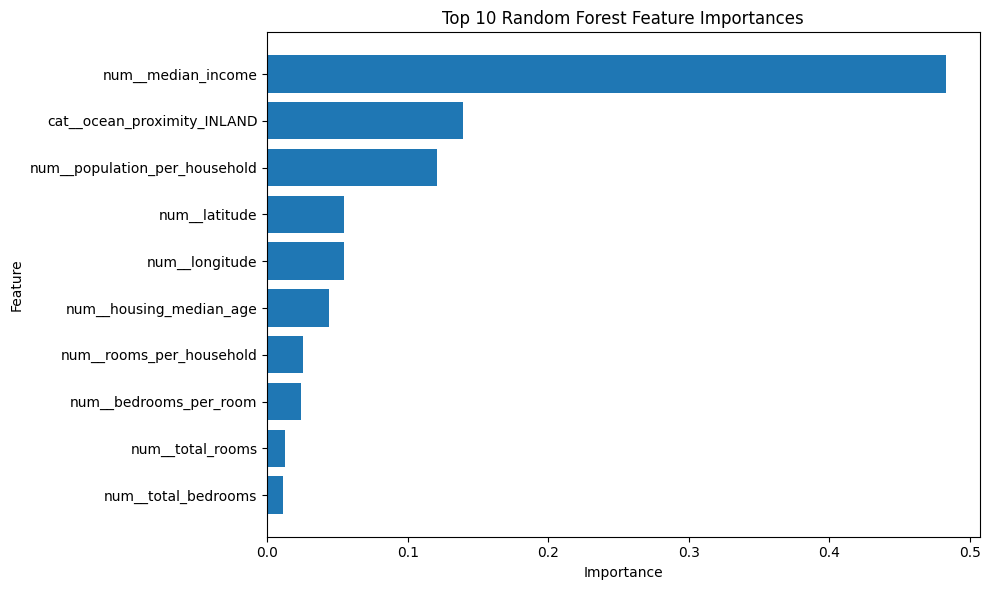

In [82]:
top_features = importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

### Random Forest Feature Importance

The Random Forest identifies `median_income` as the most important
feature, with an importance of approximately 0.483. This is consistent
with the earlier correlation analysis, where `median_income` showed the
strongest linear association with `median_house_value`.

`ocean_proximity_INLAND` and `population_per_household` are the next
most important features. Notably, `population_per_household` had very
weak linear correlation with the target, demonstrating that a feature
with low linear correlation can still provide predictive value in a
nonlinear model.

Geographic features such as latitude and longitude also contribute
meaningfully to the Random Forest predictions.

**XGBoost Regression**

In [83]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [84]:
import xgboost as xgb

print(xgb.__version__)

3.4.1


**Train XGBoost**


In [85]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_processed, y_train)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets i

In [86]:
xgb_pred = xgb_model.predict(X_test_processed)

In [87]:
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Regression")
print("------------------")
print("RMSE:", xgb_rmse)
print("MAE :", xgb_mae)
print("R²  :", xgb_r2)

XGBoost Regression
------------------
RMSE: 46613.959677008475
MAE : 30728.507465214694
R²  : 0.8341844971417525


In [88]:
##COMPARISON OF MODELS
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "SVR",
        "KNN",
        "Decision Tree",
        "Tuned Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        68057.8696,
        68067.6687,
        68058.0237,
        116976.4813,
        59709.2821,
        69955.2854,
        60184.1470,
        49836.0363,
        49526.9556,
        46613.9597
    ],
    "MAE": [
        48998.5194,
        49004.9369,
        48998.6173,
        87094.9496,
        39340.7488,
        43145.0766,
        39902.2455,
        31900.6276,
        31792.4406,
        30728.5075
    ],
    "R2": [
        0.6465,
        0.6464,
        0.6465,
        -0.0442,
        0.7279,
        0.6265,
        0.7236,
        0.8105,
        0.8128,
        0.8342
    ]
})

model_comparison.sort_values("RMSE")

,Model,RMSE,MAE,R2
9,XGBoost,46613.9597,30728.5075,0.8342
8,Tuned Random Forest,49526.9556,31792.4406,0.8128
7,Random Forest,49836.0363,31900.6276,0.8105
4,KNN,59709.2821,39340.7488,0.7279
6,Tuned Decision Tree,60184.1470,39902.2455,0.7236
0,Linear Regression,68057.8696,48998.5194,0.6465
2,Lasso,68058.0237,48998.6173,0.6465
1,Ridge,68067.6687,49004.9369,0.6464
5,Decision Tree,69955.2854,43145.0766,0.6265
3,SVR,116976.4813,87094.9496,-0.0442


**MAPE**


In [89]:
from sklearn.metrics import mean_absolute_percentage_error

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_pred
) * 100

print("XGBoost MAPE:", xgb_mape, "%")

XGBoost MAPE: 17.311112435372053 %


### Business Metric Evaluation

XGBoost achieved an RMSE of approximately $46.6K and an R² of 0.834,
meeting the case-study targets for RMSE and R².

However, the MAPE was approximately 17.31%, which is above the stated
15% target. This indicates that although the model performs well in
absolute dollar error, its relative percentage errors remain higher
for some observations.

Therefore, further error analysis is required before final model
selection.

**Residual Diagnostics.**

In [90]:
residuals = y_test - xgb_pred

In [91]:
print("Mean Residual:", residuals.mean())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())

Mean Residual: -149.58575108254604
Minimum Residual: -300472.8125
Maximum Residual: 317843.375


In [92]:
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_pred,
    "Residual": residuals.values
})

error_analysis["Absolute_Error"] = (
    error_analysis["Residual"].abs()
)

error_analysis = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
)

error_analysis.head(10)

,Actual,Predicted,Residual,Absolute_Error
872,500001.0,182157.625000,317843.375000,317843.375000
1140,500001.0,197993.156250,302007.843750,302007.843750
285,125000.0,425472.812500,-300472.812500,300472.812500
3693,500001.0,204819.875000,295181.125000,295181.125000
1649,500001.0,212528.937500,287472.062500,287472.062500
2250,500001.0,238596.937500,261404.062500,261404.062500
3755,500001.0,239596.671875,260404.328125,260404.328125
2927,17500.0,275782.531250,-258282.531250,258282.531250
3799,85000.0,343204.937500,-258204.937500,258204.937500
194,390800.0,140265.718750,250534.281250,250534.281250


**"The residual analysis shows that the model performs well overall, but a small number of observations have very large prediction errors. Several of the largest errors occur at the $500,001 target value, which is consistent with the target-value cap identified during EDA. Very low-value observations can also produce large percentage errors, contributing to the relatively high MAPE."**


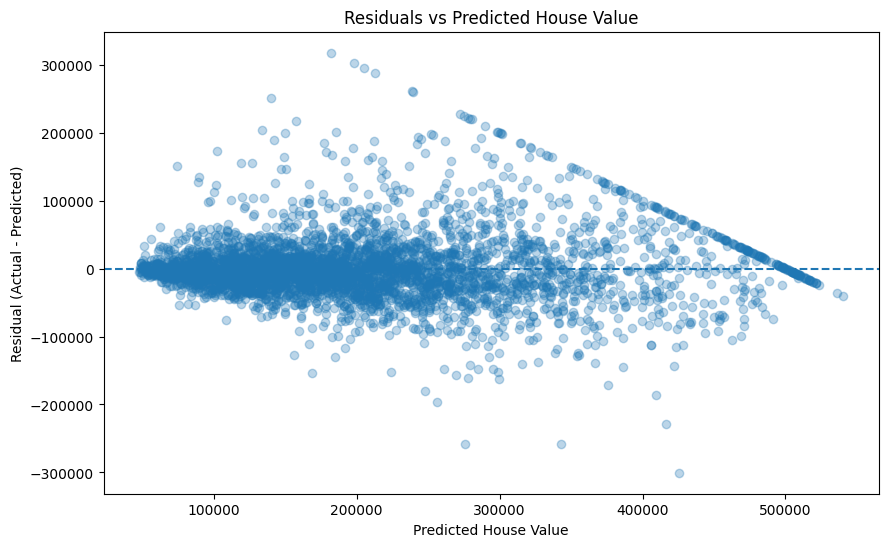

In [93]:
##let's visualize the residuals

plt.figure(figsize=(10, 6))

plt.scatter(
    xgb_pred,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Value")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted House Value")

plt.show()


### Residual Diagnostics

The residuals are largely concentrated around zero, indicating that the
XGBoost model does not show a strong overall directional bias.

A dense concentration of predictions occurs in the approximately
$100K-$300K range, with many residuals relatively close to zero.

A distinct downward diagonal pattern is visible at higher predicted
values. This is consistent with the previously identified $500,001
upper cap in the target variable: for observations recorded at
$500,001, the residual is approximately $500,001 minus the predicted
value.

The residual spread also increases across parts of the prediction
range, indicating that prediction error is not completely constant
across all house values.

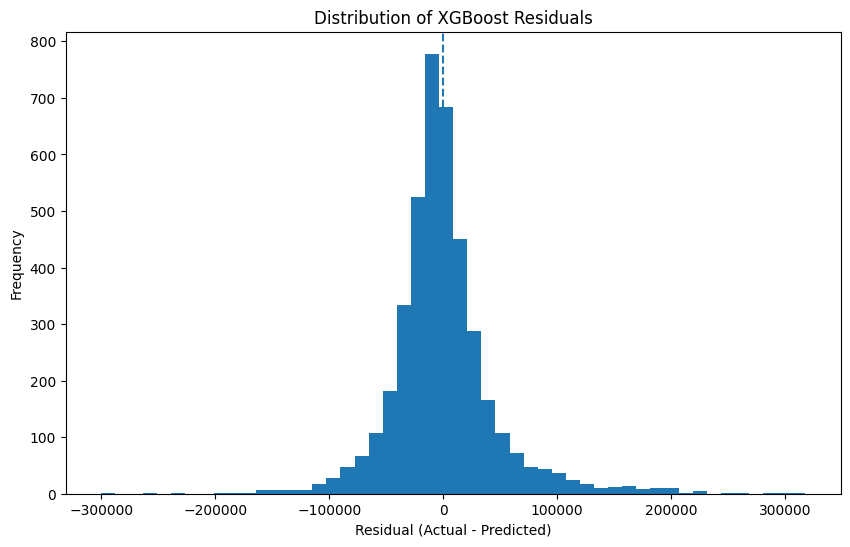

In [94]:
plt.figure(figsize=(10, 6))

plt.hist(residuals, bins=50)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of XGBoost Residuals")

plt.show()

**XGBoost Cross-Validation.**

In [95]:
##Run 5-fold cross-validation
from sklearn.model_selection import cross_val_score

xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

xgb_cv_rmse = -xgb_cv_scores

print("XGBoost Cross-Validation RMSE")
print("-----------------------------")
print("Fold RMSE:", xgb_cv_rmse)
print("Mean RMSE:", xgb_cv_rmse.mean())
print("Std RMSE :", xgb_cv_rmse.std())


XGBoost Cross-Validation RMSE
-----------------------------
Fold RMSE: [47393.23546692 47324.20973125 47943.86757116 46725.48671215
 47819.38154737]
Mean RMSE: 47441.23620576844
Std RMSE : 429.8671406666342


**"Five-fold cross-validation produced a mean RMSE of approximately $47.4K with a standard deviation of about $430, indicating relatively consistent performance across folds. The held-out test RMSE of approximately $46.6K is also close to the cross-validation mean."**

In [96]:
##CREATE LEARNING CURVE
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    xgb_model,
    X_train_processed,
    y_train,
    cv=3,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

train_rmse = -train_scores
val_rmse = -val_scores

train_rmse_mean = train_rmse.mean(axis=1)
val_rmse_mean = val_rmse.mean(axis=1)

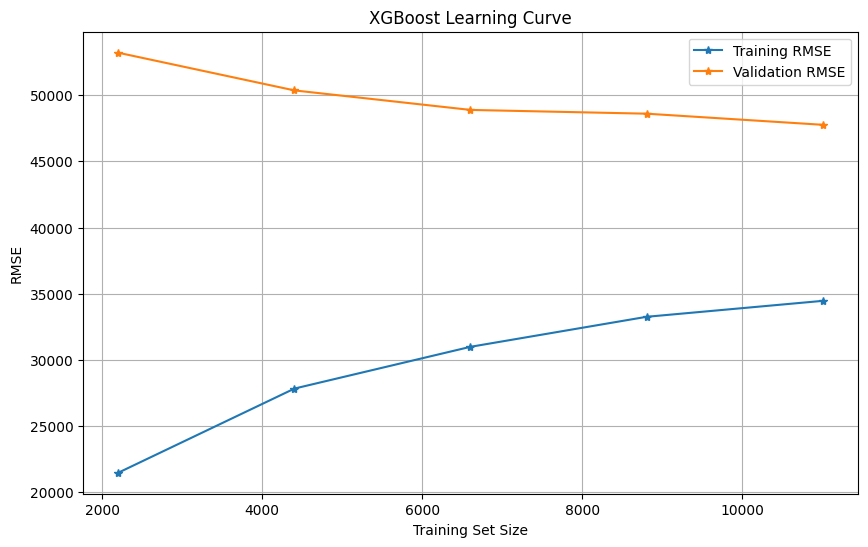

In [97]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_rmse_mean,
    marker="*",
    label="Training RMSE"
)

plt.plot(
    train_sizes,
    val_rmse_mean,
    marker="*",
    label="Validation RMSE"
)

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("XGBoost Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

### Learning Curve Analysis

The learning curve shows that training RMSE increases as more training
data is used, while validation RMSE steadily decreases.

This indicates that the model benefits from additional training data
and improves its generalization performance as the dataset grows.

At the largest training size, the validation RMSE remains higher than
the training RMSE, showing a remaining generalization gap. However,
the validation curve continues to improve rather than deteriorate,
so there is no obvious evidence of severe overfitting from the
learning curve alone.

Further improvement may be possible through additional data,
hyperparameter tuning, or feature engineering.

**HYPERPARAMETER TUNNING FOR XGBOOST

In [98]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 6, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that 

In [99]:
print("Best Parameters:")
print(xgb_random.best_params_)

print("\nBest CV RMSE:")
print(-xgb_random.best_score_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best CV RMSE:
45764.337784216295


**Test the tuned model**

In [100]:
best_xgb = xgb_random.best_estimator_

tuned_xgb_pred = best_xgb.predict(X_test_processed)

In [101]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

tuned_rmse = mean_squared_error(
    y_test,
    tuned_xgb_pred
) ** 0.5

tuned_mae = mean_absolute_error(
    y_test,
    tuned_xgb_pred
)

tuned_r2 = r2_score(
    y_test,
    tuned_xgb_pred
)

tuned_mape = mean_absolute_percentage_error(
    y_test,
    tuned_xgb_pred
) * 100

print("Tuned XGBoost Results")
print("---------------------")
print("RMSE :", tuned_rmse)
print("MAE  :", tuned_mae)
print("R²   :", tuned_r2)
print("MAPE :", tuned_mape, "%")

Tuned XGBoost Results
---------------------
RMSE : 44409.805823596886
MAE  : 28872.707822341326
R²   : 0.8494950136912894
MAPE : 16.20417158787952 %


### Tuned XGBoost Evaluation

Hyperparameter tuning improved the XGBoost model on the held-out test set.

The tuned model achieved an RMSE of approximately $44.4K, MAE of
approximately $28.9K, and R² of 0.8495. MAPE decreased from 17.31%
to 16.20%.

The model therefore meets the case-study targets for RMSE and R².
However, MAPE remains slightly above the 15% target, indicating that
relative prediction errors remain an area for further investigation.

The tuned XGBoost configuration will be used for subsequent model
explainability and robustness analysis.

In [102]:
residuals_tuned = y_test - tuned_xgb_pred

print("Mean Residual:", residuals_tuned.mean())
print("Minimum Residual:", residuals_tuned.min())
print("Maximum Residual:", residuals_tuned.max())

Mean Residual: -216.12592357073643
Minimum Residual: -252225.15625
Maximum Residual: 267688.171875


### Tuned XGBoost Residual Analysis

The tuned XGBoost model has a mean residual of approximately -$216,
which is close to zero and indicates limited overall directional bias.

However, the residual range extends from approximately -$252K to
+$268K, showing that some individual observations still have large
prediction errors.

Therefore, while the model performs well on aggregate metrics,
individual high-error observations require further investigation.

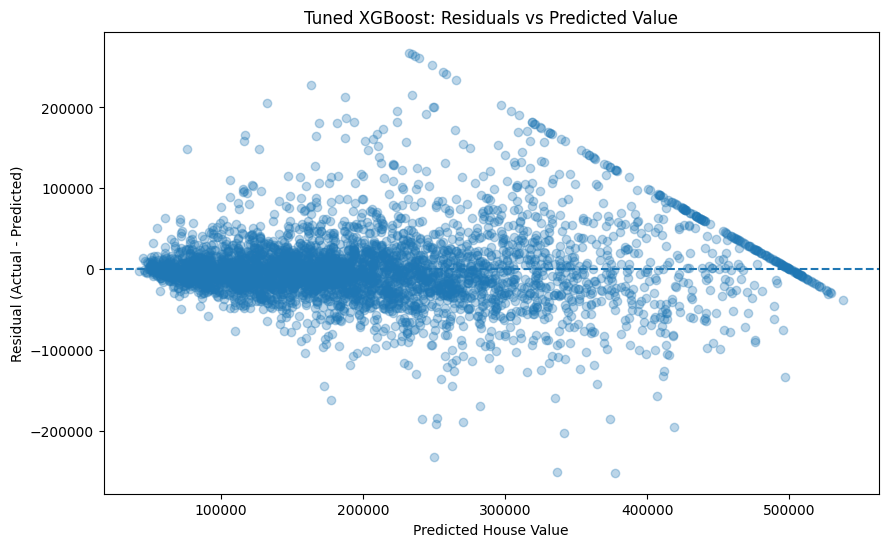

In [103]:
##visualize the tuned residuals
plt.figure(figsize=(10, 6))

plt.scatter(
    tuned_xgb_pred,
    residuals_tuned,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Value")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Tuned XGBoost: Residuals vs Predicted Value")

plt.show()



### Tuned XGBoost Residual Diagnostics

The tuned XGBoost residuals remain broadly concentrated around zero,
indicating limited overall directional bias.

However, the spread of residuals increases for higher predicted house
values, suggesting non-constant prediction error across the target range.

A distinct downward diagonal pattern is also visible in the higher-value
region. This is consistent with the previously identified $500,001
upper cap in the target variable, where residuals approximately follow:

Residual = $500,001 - Predicted Value

Hyperparameter tuning improved the overall model metrics but did not
eliminate these underlying error patterns.

In [104]:
xgb_importance = best_xgb.feature_importances_

feature_names = preprocessor.get_feature_names_out()

xgb_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_importance
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    "Importance",
    ascending=False
)

xgb_feature_importance.head(15)

,Feature,Importance
14,cat__ocean_proximity_INLAND,0.712207
7,num__median_income,0.065303
12,num__longitude_bin,0.040220
10,num__population_per_household,0.027628
8,num__rooms_per_household,0.025419
1,num__latitude,0.019014
9,num__bedrooms_per_room,0.017111
0,num__longitude,0.014290
17,cat__ocean_proximity_NEAR OCEAN,0.013247
15,cat__ocean_proximity_ISLAND,0.012638


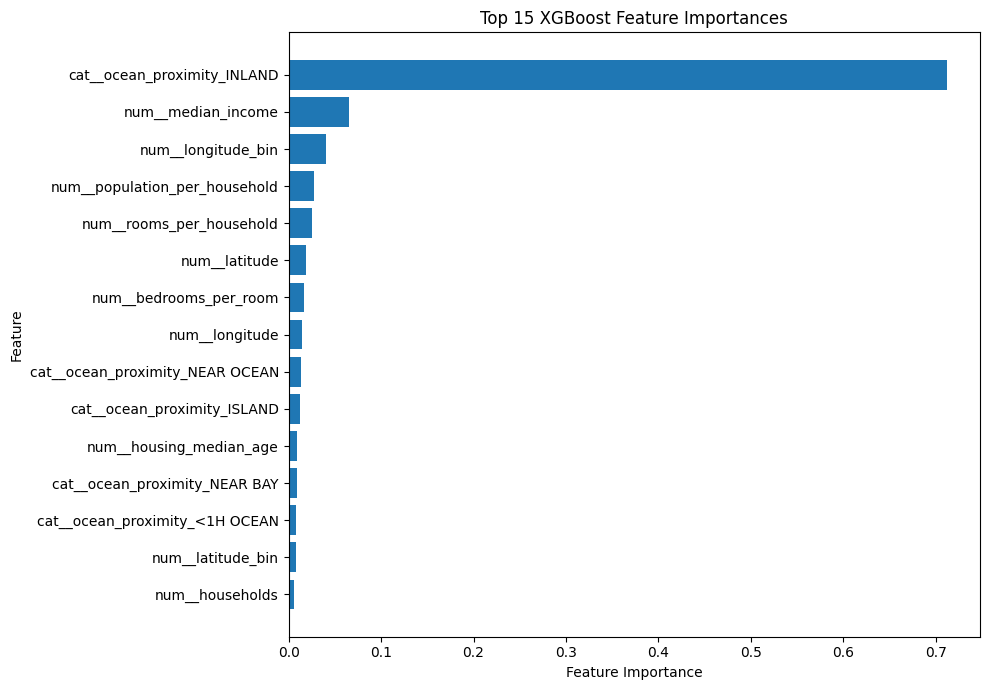

In [105]:
top_features = xgb_feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.tight_layout()
plt.show()

In [106]:
print(df.groupby("ocean_proximity")["median_house_value"].agg(
    ["count", "mean", "median", "std"]
).sort_values("median", ascending=False))

                 count           mean    median            std
ocean_proximity                                               
ISLAND               5  380440.000000  414700.0   80559.561816
NEAR BAY          2290  259212.311790  233800.0  122818.537064
NEAR OCEAN        2658  249433.977427  229450.0  122477.145927
<1H OCEAN         9136  240084.285464  214850.0  106124.292213
INLAND            6551  124805.392001  108500.0   70007.908494


**"Random Forest and XGBoost produced different feature-importance distributions. XGBoost relied much more heavily on INLAND, while Random Forest distributed importance more strongly toward median_income and other features. This difference motivates using SHAP or permutation importance for a more robust interpretation."**

In [107]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


c:\Users\Sanjay\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [108]:
##Create the SHAP explainer
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_processed)

print(shap_values.shape)

(4128, 18)


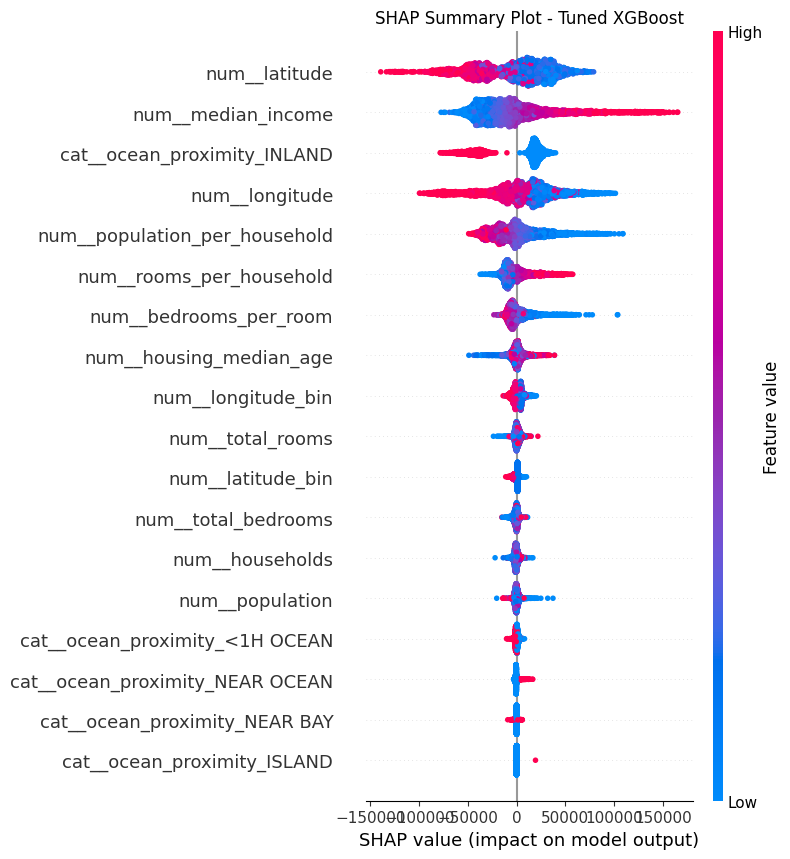

In [109]:
##SHAP Summary Plot...
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary Plot - Tuned XGBoost")
plt.tight_layout()
plt.show()


### SHAP Explainability Analysis

The SHAP summary plot provides a complementary view of feature
importance compared with the native XGBoost feature-importance
calculation.

Latitude, median income, and inland location show substantial
contributions to model predictions.

For `median_income`, higher feature values generally correspond to
positive SHAP values, indicating that higher median income tends to
push predicted house values upward.

The SHAP analysis also highlights the importance of geographic
features, particularly latitude, longitude, and ocean proximity.

The difference between native XGBoost importance and SHAP importance
demonstrates that feature importance is dependent on the explanation
method used.

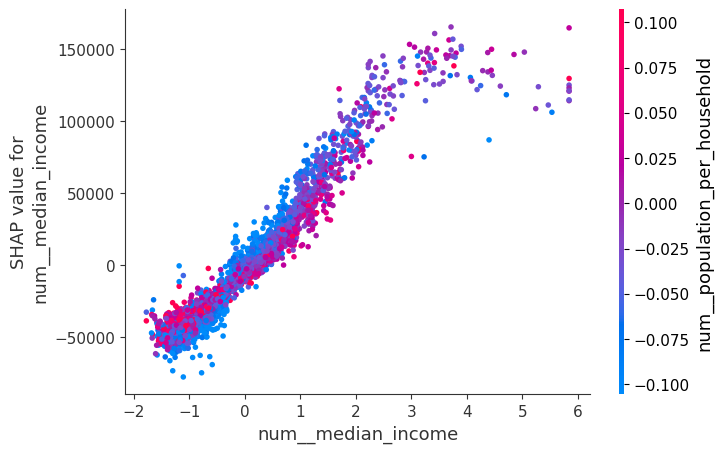

In [110]:
shap.dependence_plot(
    "num__median_income",
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

### SHAP Dependence Analysis: Median Income

The SHAP dependence plot shows a strong positive relationship between
`median_income` and its contribution to the XGBoost prediction.

At lower income values, the SHAP contribution is generally negative,
while higher income values increasingly contribute positively to the
predicted house value.

The relationship is nonlinear, with the contribution becoming less
linear at higher income levels. The color variation also indicates
that `population_per_household` and other features may interact with
the effect of median income.

This provides a more detailed interpretation than correlation alone.

In [111]:
##SHAP Local Explainability....
sample_index = 0

actual_value = y_test.iloc[sample_index]
predicted_value = tuned_xgb_pred[sample_index]

print("Actual House Value   :", actual_value)
print("Predicted House Value:", predicted_value)
#############################################
sample_shap = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_test_processed[sample_index],
    feature_names=feature_names
)


Actual House Value   : 47700.0
Predicted House Value: 56744.58


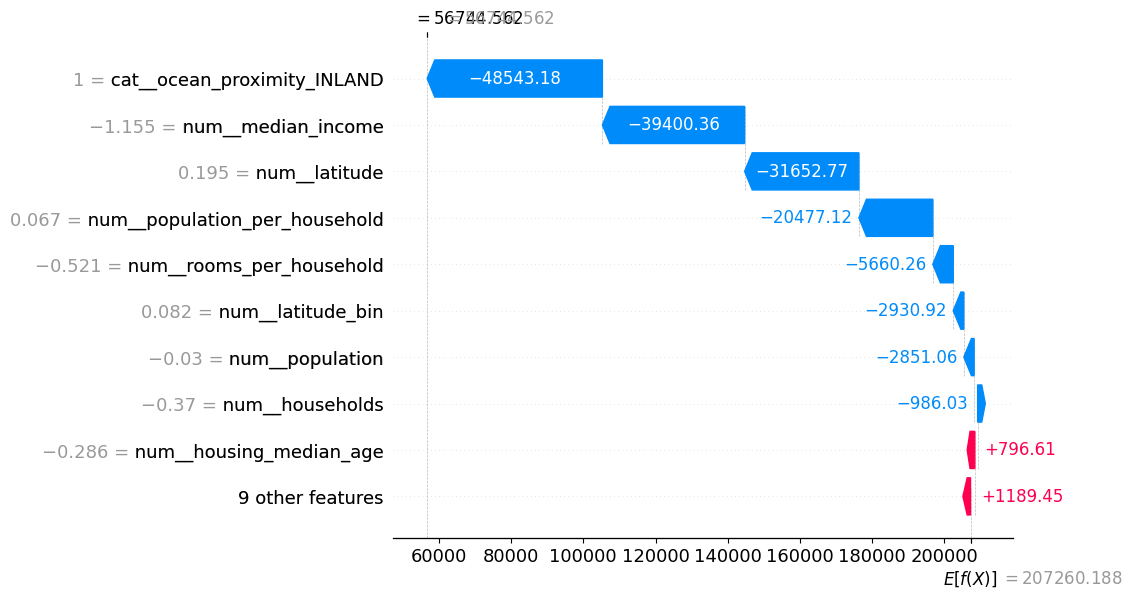

In [112]:
##Visualize the SHAP values for the selected samples
shap.plots.waterfall(sample_shap, max_display=10)

In [113]:
##Compare XGBoost vs Random Forest using the same folds..
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_cv = cross_val_score(
    best_xgb,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_cv = cross_val_score(
    best_rf,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

xgb_rmse_folds = -xgb_cv
rf_rmse_folds = -rf_cv

print("XGBoost RMSE:", xgb_rmse_folds)
print("Random Forest RMSE:", rf_rmse_folds)

XGBoost RMSE: [46035.07512023 44564.38249656 44586.71897401 45295.14907791
 43784.70889268]
Random Forest RMSE: [51452.75057764 49339.50762381 49791.5162831  51699.62892542
 48872.41074119]


In [114]:
##Paired statistical test....
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(
    xgb_rmse_folds,
    rf_rmse_folds
)

print("Paired t-test")
print("-------------")
print("t-statistic:", t_stat)
print("p-value:", p_value)


Paired t-test
-------------
t-statistic: -19.425225641999237
p-value: 4.1404995630317495e-05


### Statistical Comparison of Model Performance

A paired t-test was performed using the RMSE values from the same
five cross-validation folds for tuned XGBoost and Random Forest.

The test produced:

- t-statistic: -19.43
- p-value: 0.0000414

Since the p-value is below 0.05, the test provides statistical
evidence of a difference in cross-validation RMSE between the two
models.

XGBoost produced lower RMSE on all five paired folds. However, the
analysis is based on only five folds, so the statistical result should
be interpreted cautiously rather than treated as definitive evidence
of general model superiority.

**Sensitivity & Robustness Analysis.**

In [115]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

random_states = [21, 42, 100]

robustness_results = []

for seed in random_states:

    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=seed
    )

    # Fit preprocessing only on this training split
    preprocessor_r = preprocessor

    X_train_r_processed = preprocessor_r.fit_transform(X_train_r)
    X_test_r_processed = preprocessor_r.transform(X_test_r)

    # Use the same tuned hyperparameters
    model_r = XGBRegressor(
        subsample=0.8,
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model_r.fit(X_train_r_processed, y_train_r)

    pred_r = model_r.predict(X_test_r_processed)

    rmse_r = mean_squared_error(y_test_r, pred_r) ** 0.5
    mae_r = mean_absolute_error(y_test_r, pred_r)
    r2_r = r2_score(y_test_r, pred_r)
    mape_r = mean_absolute_percentage_error(y_test_r, pred_r) * 100

    robustness_results.append({
        "Random State": seed,
        "RMSE": rmse_r,
        "MAE": mae_r,
        "R2": r2_r,
        "MAPE": mape_r
    })

robustness_df = pd.DataFrame(robustness_results)

robustness_df

,Random State,RMSE,MAE,R2,MAPE
0,21,44664.347853,29153.065756,0.851612,16.119597
1,42,44409.805824,28872.707822,0.849495,16.204172
2,100,43071.102196,27969.763424,0.862318,15.523031


### Sensitivity and Robustness Analysis

The tuned XGBoost model was evaluated using three different train/test
split random states: 21, 42, and 100.

RMSE ranged from approximately $43.1K to $44.7K, while R² remained
between 0.8495 and 0.8623. MAPE ranged from approximately 15.5% to
16.2%.

The relatively narrow variation across the tested splits indicates
that model performance is reasonably stable with respect to the
train/test split used in this experiment.

The results should not be interpreted as proof of universal model
stability, since only three random splits were evaluated.

In [116]:
####DELPOYMENT_READY_PIPLINE..................
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_xgb)
])

In [117]:
final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [118]:
###TEST_THE PIPELINE ON THE TEST SET####

pipeline_pred = final_pipeline.predict(X_test)

pipeline_rmse = mean_squared_error(
    y_test,
    pipeline_pred
) ** 0.5

pipeline_mae = mean_absolute_error(
    y_test,
    pipeline_pred
)

pipeline_r2 = r2_score(
    y_test,
    pipeline_pred
)

pipeline_mape = mean_absolute_percentage_error(
    y_test,
    pipeline_pred
) * 100

print("Final Pipeline Results")
print("----------------------")
print("RMSE :", pipeline_rmse)
print("MAE  :", pipeline_mae)
print("R²   :", pipeline_r2)
print("MAPE :", pipeline_mape, "%")

Final Pipeline Results
----------------------
RMSE : 44409.805823596886
MAE  : 28872.707822341326
R²   : 0.8494950136912894
MAPE : 16.20417158787952 %


### Deployment-Ready Pipeline Validation

The preprocessing steps and tuned XGBoost model were integrated into a
single scikit-learn pipeline.

The integrated pipeline produced the same test-set performance as the
previous separate preprocessing and modeling workflow:

- RMSE: approximately $44.4K
- MAE: approximately $28.9K
- R²: 0.8495
- MAPE: 16.20%

This confirms that the complete pipeline preserves the validated model
performance while providing a reproducible preprocessing and prediction
workflow suitable for serialization and deployment.

***Model Serialization***

In [119]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "california_housing_xgb.joblib"

joblib.dump(final_pipeline, model_path)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: ..\models\california_housing_xgb.joblib


In [120]:
##Load the saved model.....

loaded_pipeline = joblib.load(model_path)

print("Model loaded successfully!")


Model loaded successfully!


In [121]:
##Make predictions with the loaded model....
loaded_pred = loaded_pipeline.predict(X_test)

loaded_rmse = mean_squared_error(
    y_test,
    loaded_pred
) ** 0.5

print("Loaded Model RMSE:", loaded_rmse)

Loaded Model RMSE: 44409.805823596886


### Model Serialization and Reload Validation

The complete preprocessing and tuned XGBoost pipeline was serialized
using Joblib and saved as:

`models/california_housing_xgb.joblib`

The serialized pipeline was subsequently loaded and evaluated on the
held-out test set.

The loaded model achieved an RMSE of approximately $44.4K, matching the
original pipeline performance. This confirms that the serialized model
can be restored and used for inference without retraining.

***Batch Inference***

In [122]:
batch_data = X_test.head(5).copy()

batch_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,latitude_bin,longitude_bin
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,INLAND,4.192201,NaN,3.877437,3,5
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,INLAND,5.039384,NaN,2.679795,2,4
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,NEAR BAY,3.977155,NaN,1.360332,5,1
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,<1H OCEAN,6.163636,NaN,3.444444,1,5
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,NEAR OCEAN,5.492991,NaN,2.483645,4,2


In [123]:
loaded_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [124]:
##Now predict:
batch_predictions = loaded_pipeline.predict(batch_data)

print("Batch Predictions:")
print(batch_predictions)

Batch Predictions:
[ 56744.58  69329.22 494564.56 245987.94 261851.33]


In [125]:
####Create an output table...
batch_output = batch_data.copy()

batch_output["Predicted_House_Value"] = batch_predictions

batch_output

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,latitude_bin,longitude_bin,Predicted_House_Value
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,INLAND,4.192201,NaN,3.877437,3,5,56744.578125
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,INLAND,5.039384,NaN,2.679795,2,4,69329.218750
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,NEAR BAY,3.977155,NaN,1.360332,5,1,494564.562500
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,<1H OCEAN,6.163636,NaN,3.444444,1,5,245987.937500
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,NEAR OCEAN,5.492991,NaN,2.483645,4,2,261851.328125


### Batch Inference Simulation

A batch inference workflow was simulated using five housing records
from the test dataset.

The serialized deployment pipeline was used to process the raw records,
automatically perform preprocessing and generate predicted house values.

The workflow demonstrates how multiple incoming housing records can be
passed through the saved model to generate predictions without manually
repeating preprocessing steps.

The pipeline also handled missing `total_bedrooms` values through the
configured median-imputation step.

In [126]:
##Save the batch predictions.....
output_path = Path("../outputs/batch_predictions.csv")

output_path.parent.mkdir(exist_ok=True)

batch_output.to_csv(
    output_path,
    index=False
)

print("Batch predictions saved successfully!")
print("Path:", output_path)

Batch predictions saved successfully!
Path: ..\outputs\batch_predictions.csv


In [127]:
###Check the production batch...
monitor_data = pd.read_csv("../outputs/batch_predictions.csv")

print("Monitoring Dataset Shape:", monitor_data.shape)
print("\nColumns:")
print(monitor_data.columns.tolist())

print("\nPrediction Summary:")
print(monitor_data["Predicted_House_Value"].describe())

Monitoring Dataset Shape: (5, 15)

Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'latitude_bin', 'longitude_bin', 'Predicted_House_Value']

Prediction Summary:
count         5.000000
mean     225695.526000
std      178188.401334
min       56744.580000
25%       69329.220000
50%      245987.940000
75%      261851.330000
max      494564.560000
Name: Predicted_House_Value, dtype: float64


In [128]:
###Create a Production Monitoring Sample..

# Reference data for monitoring
reference_data = X_test.copy()

print("Reference dataset shape:", reference_data.shape)
print("\nReference feature summary:")
print(reference_data[[
    "median_income",
    "housing_median_age",
    "population",
    "households"
]].describe())


Reference dataset shape: (4128, 14)

Reference feature summary:
       median_income  housing_median_age    population   households
count    4128.000000         4128.000000   4128.000000  4128.000000
mean        3.830338           28.764293   1421.571705   497.750727
std         1.881515           12.518304   1114.023136   387.770570
min         0.499900            1.000000      8.000000     2.000000
25%         2.548500           18.000000    781.000000   278.000000
50%         3.500000           29.000000   1160.000000   406.000000
75%         4.645925           37.000000   1722.000000   598.000000
max        15.000100           52.000000  16122.000000  5189.000000


In [129]:
# Simulate production data
production_data = reference_data.copy()

# Introduce controlled distribution shifts
production_data["median_income"] = (
    production_data["median_income"] * 1.15
)

production_data["population"] = (
    production_data["population"] * 1.20
)

print("Production dataset shape:", production_data.shape)

print("\nProduction feature summary:")
print(production_data[[
    "median_income",
    "housing_median_age",
    "population",
    "households"
]].describe())

Production dataset shape: (4128, 14)

Production feature summary:
       median_income  housing_median_age    population   households
count    4128.000000         4128.000000   4128.000000  4128.000000
mean        4.404889           28.764293   1705.886047   497.750727
std         2.163743           12.518304   1336.827764   387.770570
min         0.574885            1.000000      9.600000     2.000000
25%         2.930775           18.000000    937.200000   278.000000
50%         4.025000           29.000000   1392.000000   406.000000
75%         5.342814           37.000000   2066.400000   598.000000
max        17.250115           52.000000  19346.400000  5189.000000


In [131]:
##KS Test for Data Drift

from scipy.stats import ks_2samp

features_to_monitor = [
    "median_income",
    "housing_median_age",
    "population",
    "households"
]

drift_results = []

for feature in features_to_monitor:
    statistic, p_value = ks_2samp(
        reference_data[feature].dropna(),
        production_data[feature].dropna()
    )

    drift_results.append({
        "Feature": feature,
        "KS Statistic": statistic,
        "P-Value": p_value,
        "Drift Detected": p_value < 0.05
    })

drift_results = pd.DataFrame(drift_results)

print(drift_results)

              Feature  KS Statistic       P-Value  Drift Detected
0       median_income      0.131298  2.038731e-31            True
1  housing_median_age      0.000000  1.000000e+00           False
2          population      0.129845  9.855129e-31            True
3          households      0.000000  1.000000e+00           False


In [132]:
# Generate predictions for reference and simulated production data

reference_predictions = loaded_pipeline.predict(reference_data)

production_predictions = loaded_pipeline.predict(production_data)

print("Reference predictions:")
print(pd.Series(reference_predictions).describe())

print("\nProduction predictions:")
print(pd.Series(production_predictions).describe())

Reference predictions:
count      4128.000000
mean     205716.437500
std      104622.546875
min       41974.914062
25%      126169.414062
50%      184814.343750
75%      262969.765625
max      537933.500000
dtype: float64

Production predictions:
count      4128.000000
mean     217842.796875
std      110837.093750
min       45831.414062
25%      132983.796875
50%      194345.226562
75%      284880.312500
max      543072.750000
dtype: float64


In [133]:
# KS test for prediction drift

prediction_ks_stat, prediction_p_value = ks_2samp(
    reference_predictions,
    production_predictions
)

print("Prediction Drift Analysis")
print("-------------------------")
print("KS Statistic:", prediction_ks_stat)
print("P-Value:", prediction_p_value)

if prediction_p_value < 0.05:
    print("⚠️ Prediction drift detected")
else:
    print("✅ No statistically significant prediction drift detected")

Prediction Drift Analysis
-------------------------
KS Statistic: 0.048207364341085274
P-Value: 0.00013602467430441883
⚠️ Prediction drift detected


### Production Monitoring and Drift Detection

A monitoring framework was implemented to compare reference data with
simulated production data.

The Kolmogorov-Smirnov test was used to detect distribution changes in
selected numerical features. The simulated production data showed
statistically significant drift in `median_income` and `population`,
while `housing_median_age` and `households` showed no detected drift.

Prediction drift was also evaluated by comparing the distributions of
reference and production predictions. The KS test produced a statistic
of approximately 0.0482 with a p-value of 0.000136, indicating a
statistically significant difference between the two prediction
distributions.

The production data used here is simulated for demonstration purposes.
Detected drift should therefore be treated as a monitoring example
rather than evidence of actual production degradation. In a real
deployment, detected drift would trigger further investigation,
production performance evaluation, and potential model retraining.

In [135]:
from sklearn.feature_selection import SelectKBest, f_regression

# Feature selection on the processed training data
selector = SelectKBest(
    score_func=f_regression,
    k="all"
)

selector.fit(X_train_processed, y_train)

feature_scores = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "F_Score": selector.scores_,
    "P_Value": selector.pvalues_
})

feature_scores = feature_scores.sort_values(
    "F_Score",
    ascending=False
)

feature_scores

,Feature,F_Score,P_Value
7,num__median_income,15057.439100,0.000000e+00
14,cat__ocean_proximity_INLAND,5019.790515,0.000000e+00
13,cat__ocean_proximity_<1H OCEAN,1182.665117,2.233108e-250
9,num__bedrooms_per_room,1171.665876,3.804451e-248
16,cat__ocean_proximity_NEAR BAY,445.720380,1.198665e-97
8,num__rooms_per_household,425.373449,2.473178e-93
1,num__latitude,344.579030,3.821798e-76
11,num__latitude_bin,335.820348,2.826428e-74
17,cat__ocean_proximity_NEAR OCEAN,303.080897,2.800850e-67
3,num__total_rooms,301.823325,5.203989e-67


***dimensionality reduction.***


In [136]:
##Principal Component Analysis.


from sklearn.decomposition import PCA


pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_processed)

print("Original number of features:", X_train_processed.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original number of features: 18
Number of PCA components: 8
Explained variance: 0.961942897190837


### Dimensionality Reduction using PCA

Principal Component Analysis (PCA) was evaluated as a dimensionality
reduction technique on the processed feature space.

The original 18 processed features were reduced to 8 principal components
while retaining approximately 96.19% of the total variance.

Although PCA provides substantial dimensionality reduction, it was not
included in the final XGBoost production pipeline. The final model retains
the original engineered features to preserve feature interpretability and
support model explainability using SHAP.

# 27. Final Executive Summary

## Business Objective

The objective of this case study was to develop an end-to-end machine
learning solution for predicting California median house values using
housing, demographic, geographic, and ocean-proximity information.

## Data and Quality Findings

The dataset contains 20,640 observations and 10 original features.
The data-quality audit identified 207 missing values in
`total_bedrooms`, representing approximately 1% of the dataset.

EDA revealed skewed distributions in several numerical variables,
substantial multicollinearity among housing-related variables, clear
geographic patterns, and a concentration of target values at $500,001,
suggesting an upper-value cap in the recorded target.

## Feature Engineering

Domain-informed features were created, including:

- `rooms_per_household`
- `bedrooms_per_room`
- `population_per_household`

Categorical encoding and spatial discretization were also applied.

## Model Development

Multiple regression approaches were evaluated, including linear,
regularized, nonlinear, tree-based, and ensemble models.

The tuned XGBoost model produced the strongest observed test-set
performance in this workflow.

### Final Model Performance

- RMSE: approximately $44.4K
- MAE: approximately $28.9K
- R²: 0.8495
- MAPE: 16.20%

The model satisfies the case-study targets for RMSE below $60K and
R² above 0.75. The MAPE target of below 15% was not achieved.

## Model Explainability

SHAP analysis was used to investigate global and local model behavior.
`median_income`, geographic variables, ocean proximity, and engineered
housing features showed meaningful contributions to predictions.

Native XGBoost feature importance and SHAP rankings were interpreted
separately because they represent different measures of feature
importance.

## Robustness

The tuned XGBoost model was evaluated across multiple train/test random
states. RMSE ranged approximately from $43.1K to $44.7K, while R²
remained between 0.8495 and 0.8623.

These results indicate reasonably stable performance across the tested
splits, although the limited number of splits does not establish
universal model stability.

## Deployment Readiness

The preprocessing and trained XGBoost model were integrated into a
single scikit-learn pipeline.

The complete pipeline was serialized using Joblib and successfully
reloaded. The reloaded pipeline reproduced the validated test-set
performance.

Batch inference was also demonstrated successfully.

## Production Monitoring

A monitoring framework was demonstrated using simulated production data.

KS testing detected distribution shifts in `median_income` and
`population`. Prediction drift was also detected when comparing
reference and simulated production prediction distributions.

Because the production dataset was simulated, these results demonstrate
the monitoring methodology rather than actual production degradation.

## Dimensionality Reduction

SelectKBest identified `median_income` as the strongest individual
univariate signal.

PCA reduced the processed feature space from 18 features to 8 principal
components while retaining approximately 96.19% of the variance.

PCA was not included in the final production pipeline because retaining
interpretable original features supports model explainability.

## Final Outcome

The project demonstrates a complete data science workflow covering data
quality assessment, EDA, feature engineering, preprocessing, model
comparison, hyperparameter tuning, evaluation, explainability,
robustness analysis, statistical comparison, deployment preparation,
serialization, batch inference, and production monitoring.

In [137]:
print("Latitude bin boundaries:")
print(pd.cut(df["latitude"], bins=10, retbins=True)[1])

print("\nLongitude bin boundaries:")
print(pd.cut(df["longitude"], bins=10, retbins=True)[1])

Latitude bin boundaries:
[32.53059 33.481   34.422   35.363   36.304   37.245   38.186   39.127
 40.068   41.009   41.95   ]

Longitude bin boundaries:
[-124.36004 -123.346   -122.342   -121.338   -120.334   -119.33
 -118.326   -117.322   -116.318   -115.314   -114.31   ]
